In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

load dataset

In [2]:
df = pd.read_csv("data.csv")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
# Remove unnecessary columns
df = df.drop(["id", "Unnamed: 32"], axis=1)
# Convert target into numbers
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

seprate feature and target

In [5]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

standardixe scalar

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


applt pca

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [8]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["diagnosis"] = y.values

basic information

In [9]:
print("="*50)
print("PCA ANALYSIS")
print("="*50)

print("\nOriginal Shape :", X_scaled.shape)
print("Reduced Shape  :", X_pca.shape)

print("\nNumber of Principal Components:")
print(pca.n_components_)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(pca.explained_variance_ratio_.sum())

print("\nEigenvalues:")
print(pca.explained_variance_)

print("\nFirst Five Rows of PCA Data:")
print(pca_df.head())

PCA ANALYSIS

Original Shape : (569, 30)
Reduced Shape  : (569, 2)

Number of Principal Components:
2

Explained Variance Ratio:
[0.44272026 0.18971182]

Total Variance Explained:
0.6324320765155944

Eigenvalues:
[13.30499079  5.7013746 ]

First Five Rows of PCA Data:
        PC1        PC2  diagnosis
0  9.192837   1.948583          1
1  2.387802  -3.768172          1
2  5.733896  -1.075174          1
3  7.122953  10.275589          1
4  3.935302  -1.948072          1


pca loading

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

print("\nPCA Loadings:")
print(loadings)


PCA Loadings:
                              PC1       PC2
radius_mean              0.218902 -0.233857
texture_mean             0.103725 -0.059706
perimeter_mean           0.227537 -0.215181
area_mean                0.220995 -0.231077
smoothness_mean          0.142590  0.186113
compactness_mean         0.239285  0.151892
concavity_mean           0.258400  0.060165
concave points_mean      0.260854 -0.034768
symmetry_mean            0.138167  0.190349
fractal_dimension_mean   0.064363  0.366575
radius_se                0.205979 -0.105552
texture_se               0.017428  0.089980
perimeter_se             0.211326 -0.089457
area_se                  0.202870 -0.152293
smoothness_se            0.014531  0.204430
compactness_se           0.170393  0.232716
concavity_se             0.153590  0.197207
concave points_se        0.183417  0.130322
symmetry_se              0.042498  0.183848
fractal_dimension_se     0.102568  0.280092
radius_worst             0.227997 -0.219866
texture_worst    

In [11]:
print("\nPercentage of Variance Explained")

for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {variance*100:.2f}%")

print(f"\nTotal Variance Explained = {pca.explained_variance_ratio_.sum()*100:.2f}%")



Percentage of Variance Explained
PC1: 44.27%
PC2: 18.97%

Total Variance Explained = 63.24%


scatter plot

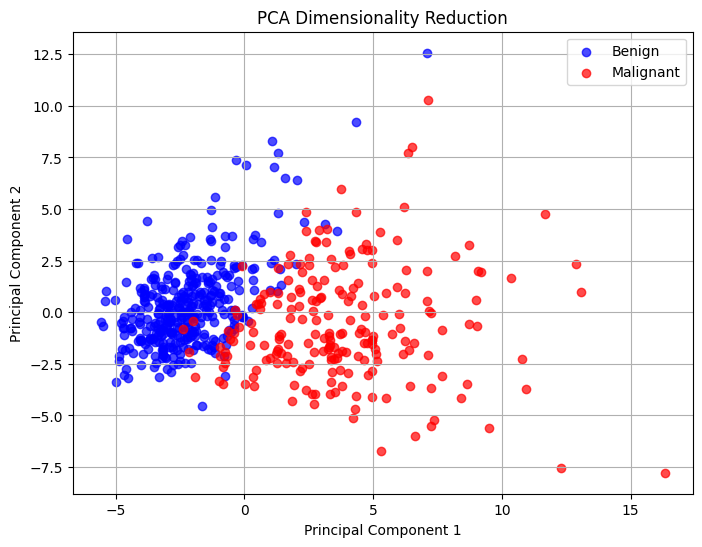

In [12]:
plt.figure(figsize=(8,6))

colors = ["blue", "red"]
labels = ["Benign", "Malignant"]

for value, color, label in zip([0,1], colors, labels):
    plt.scatter(
        pca_df[pca_df["diagnosis"] == value]["PC1"],
        pca_df[pca_df["diagnosis"] == value]["PC2"],
        c=color,
        label=label,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Dimensionality Reduction")
plt.legend()
plt.grid(True)

plt.show()

scree plot

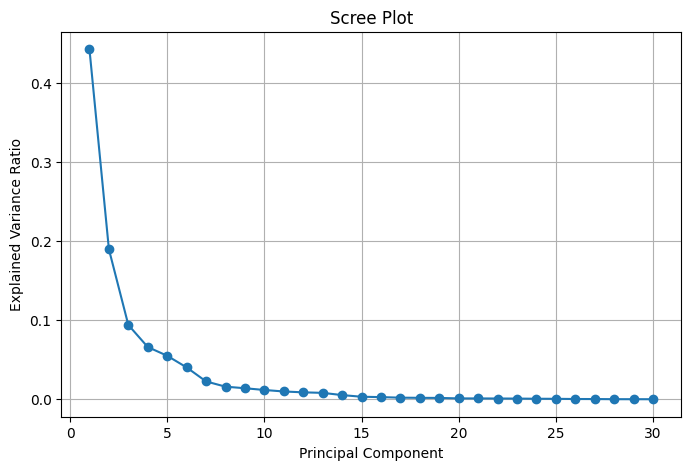

In [13]:
pca_full = PCA()

pca_full.fit(X_scaled)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)

plt.show()


Cumulative Variance Plot

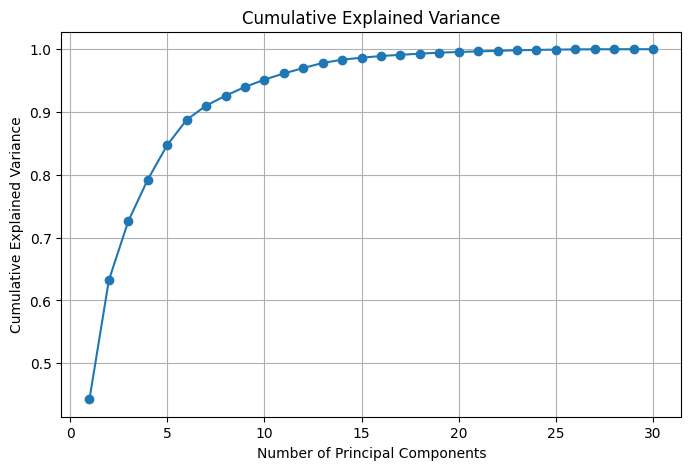

In [14]:
cum_var = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)

plt.show()

 Interpretation

In [15]:
print("\nInterpretation")
print("-"*50)

print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.2f}% of the variance.")
print(f"PC2 explains {pca.explained_variance_ratio_[1]*100:.2f}% of the variance.")
print(f"Together, PC1 and PC2 explain {pca.explained_variance_ratio_.sum()*100:.2f}% of the total variance.")

if pca.explained_variance_ratio_.sum() > 0.60:
    print("\nThe first two principal components retain most of the important information in the dataset.")
else:
    print("\nMore principal components may be required to preserve the information.")


Interpretation
--------------------------------------------------
PC1 explains 44.27% of the variance.
PC2 explains 18.97% of the variance.
Together, PC1 and PC2 explain 63.24% of the total variance.

The first two principal components retain most of the important information in the dataset.
